In [34]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import shap
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## Load Dataset

In [35]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding

In [36]:
df.shape

(7043, 21)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [38]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [39]:
df['Churn'].value_counts(normalize= True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Data Cleaning

In [40]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

In [41]:
# Drop ID column (NO predictive value)
df.drop(columns=['customerID'], inplace=True)

## EXPLORATORY DATA ANALYSIS (EDA)

##### Target Distribution (WHY accuracy is misleading)

Why this plot exists: </br>
To prove class imbalance visually. Interviewers expect this

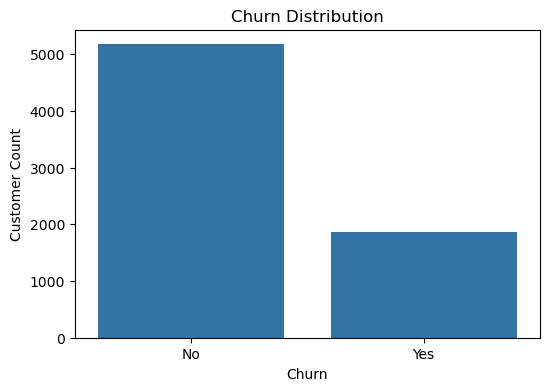

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customer Count")
plt.show()


##### Churn vs Contract Type (STRONG BUSINESS SIGNAL)

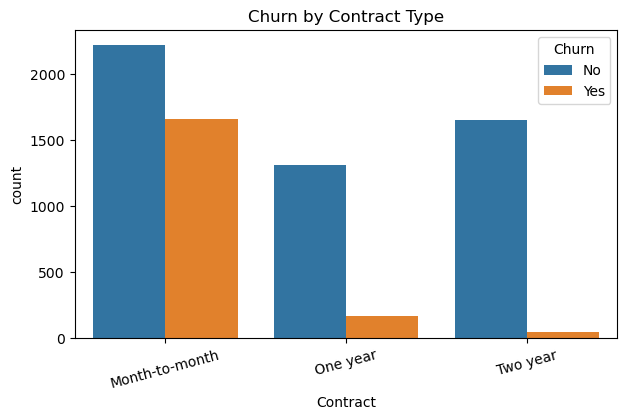

In [43]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()


##### Churn vs Tenure (BEHAVIORAL INSIGHT)

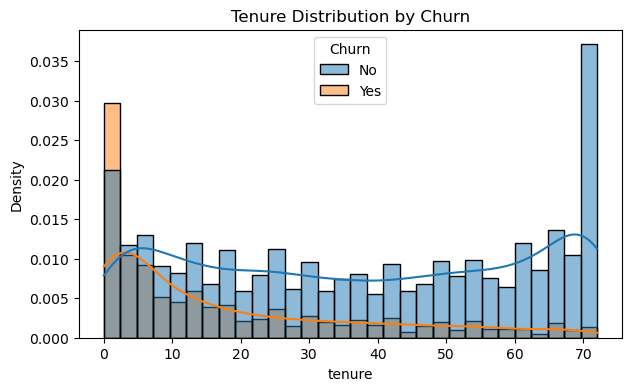

In [44]:
plt.figure(figsize=(7,4))
sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    bins=30,
    kde=True,
    stat='density'
)
plt.title("Tenure Distribution by Churn")
plt.show()

##### Monthly Charges vs Churn (PRICING SENSITIVITY)

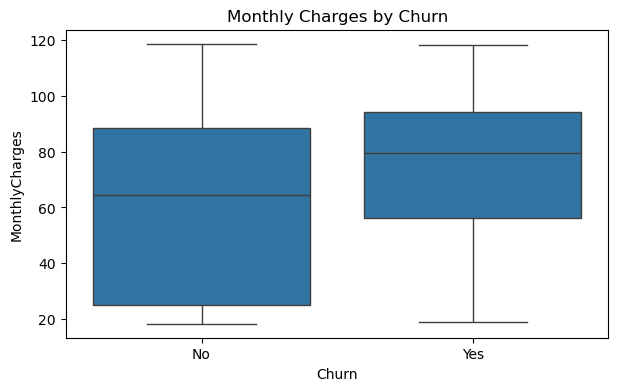

In [45]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges by Churn")
plt.show()

##### Payment Method vs Churn (NON-OBVIOUS RISK)

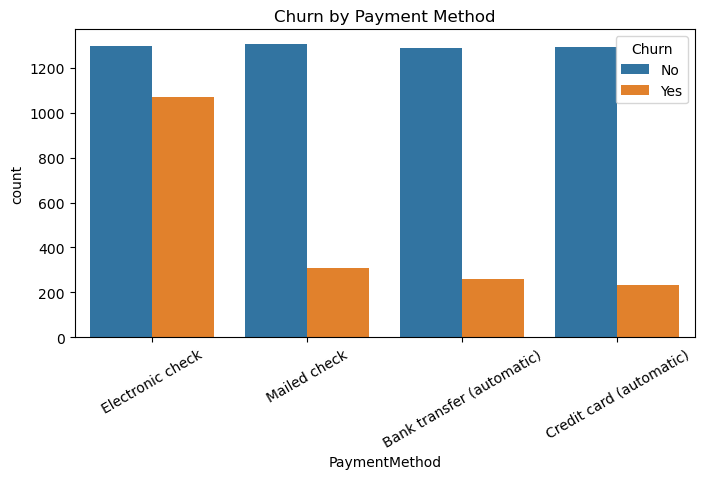

In [47]:
plt.figure(figsize=(8,4))
sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)
plt.xticks(rotation=30)
plt.title("Churn by Payment Method")
plt.show()

##### Internet Service vs Churn

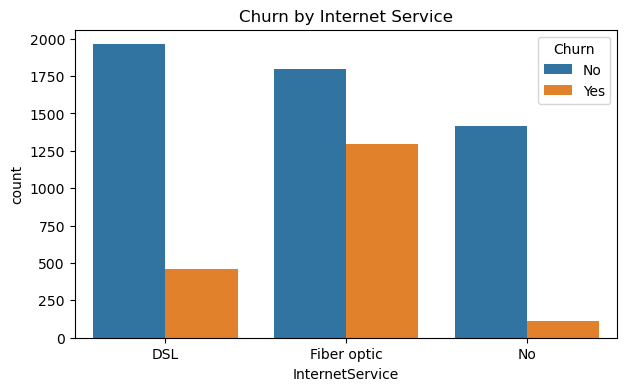

In [48]:
plt.figure(figsize=(7,4))
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)
plt.title("Churn by Internet Service")
plt.show()

## 📌 TRANSITION STATEMENT

## Feature Engineering

In [50]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [51]:
df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

df['service_count'] = (
    (df[['PhoneService','InternetService']] != 'No').sum(axis=1)
)

In [52]:
df['contract_risk'] = df['Contract'].apply(
    lambda x: 1 if x == 'Month-to-month' else 0
)

df['payment_risk'] = df['PaymentMethod'].apply(
    lambda x: 1 if x == 'Electronic check' else 0
)

## Feature / Target Split

In [ ]:
# -----------------------------
# Feature Groups
# -----------------------------

target = "Churn"

numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "avg_monthly_spend",
    "service_count",
    "contract_risk",
    "payment_risk"
]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [53]:
X = df[numeric_features + categorical_features]
y = df[target]

## Encoding Strategy

##### Professional logic:
One-hot encode low-cardinality categorical features. </br>Let CatBoost handle raw categorical values

In [54]:
# cat_features = X.select_dtypes(include='object').columns.tolist()

# X_encoded = pd.get_dummies(X, drop_first=True)

# *****CREATE THE PREPROCESSOR  (New cell)*****

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## Train–Test Split (Stratified)
Why: Preserve churn ratio.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False
)

stack = StackingClassifier(
    estimators=[
        ("cat", cat),
        ("lr", lr)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=False
)

## BUILD THE PIPELINE

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", stack)   # your FINAL chosen model
])

# This wraps:
#     preprocessing
#     stacking ensemble
#     into one object.

## TRAIN THE PIPELINE

In [ ]:
pipeline.fit(X_train, y_train)

## EVALUATION

In [ ]:
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

## SAVE THE PIPELINE

In [ ]:
import joblib

joblib.dump(pipeline, "churn_pipeline.pkl")
joblib.dump(best_threshold, "threshold.pkl")

## Baseline Model (Logistic Regression)
Why: Benchmark value of complexity.

In [56]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

lr_pred = lr.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, lr_pred))

ROC-AUC: 0.8507805751466991


## Tree Ensembles (Bagging)

##### Random Forest

In [57]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)

rf_pred = rf.predict_proba(X_test)[:,1]
print("RF ROC-AUC:", roc_auc_score(y_test, rf_pred))

RF ROC-AUC: 0.8303370191528021


##### Extra Trees

In [58]:
et = ExtraTreesClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
et.fit(X_train, y_train)

et_pred = et.predict_proba(X_test)[:,1]
print("ET ROC-AUC:", roc_auc_score(y_test, et_pred))

ET ROC-AUC: 0.8067898619555253


## Boosting Models (CORE MODELS)

##### CatBoost (KING for churn)

In [59]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=False
)

cat_model.fit(
    X_train, y_train
)

cat_pred = cat_model.predict_proba(X_test)[:,1]
print("CatBoost ROC-AUC:", roc_auc_score(y_test, cat_pred))


CatBoost ROC-AUC: 0.8369984676434474


##### LightGBM

In [60]:
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict_proba(X_test)[:,1]

print("LightGBM ROC-AUC:", roc_auc_score(y_test, lgbm_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1402, number of negative: 3880
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002202 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 899
[LightGBM] [Info] Number of data points in the train set: 5282, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM ROC-AUC: 0.8285456844139812


##### XGBoost

In [61]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    random_state=RANDOM_STATE,
    eval_metric='auc'
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict_proba(X_test)[:,1]

print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_pred))

XGBoost ROC-AUC: 0.8297139821743578


## Voting Ensemble (Soft Voting)

Why: Probability averaging reduces individual bias.

In [62]:
voting = VotingClassifier(
    estimators=[
        ('cat', cat_model),
        ('lgbm', lgbm),
        ('xgb', xgb)
    ],
    voting='soft'
)

voting.fit(X_train, y_train)
vote_pred = voting.predict_proba(X_test)[:,1]

print("Voting ROC-AUC:", roc_auc_score(y_test, vote_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1402, number of negative: 3880
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000743 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 899
[LightGBM] [Info] Number of data points in the train set: 5282, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Voting ROC-AUC: 0.8342233467593804


## Stacking Ensemble (INDUSTRY-LEVEL)

Why: Meta-learning captures complementary strengths.

In [63]:
stack = StackingClassifier(
    estimators=[
        ('cat', cat_model),
        ('lgbm', lgbm),
        ('lr', lr)
    ],
    final_estimator=LogisticRegression(),
    passthrough=False
)

stack.fit(X_train, y_train)
stack_pred = stack.predict_proba(X_test)[:,1]

print("Stacking ROC-AUC:", roc_auc_score(y_test, stack_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1402, number of negative: 3880
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000774 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 899
[LightGBM] [Info] Number of data points in the train set: 5282, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1121, number of negative: 3104
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000632 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=

## Threshold Optimization (BUSINESS CRITICAL)

In [64]:
precision, recall, thresholds = precision_recall_curve(y_test, stack_pred)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
best_threshold = thresholds[np.argmax(f1_scores)]

best_threshold

np.float64(0.31923655878914636)

#### Apply Optimized Threshold

In [65]:
final_preds = (stack_pred >= best_threshold).astype(int)

print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1294
           1       0.56      0.75      0.64       467

    accuracy                           0.78      1761
   macro avg       0.73      0.77      0.74      1761
weighted avg       0.81      0.78      0.79      1761



#### Precision–Recall Curve

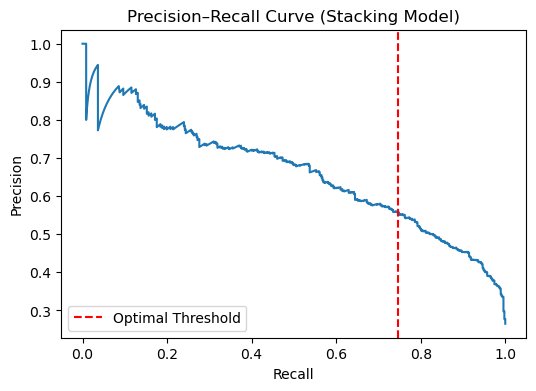

In [68]:
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.axvline(
    recall[np.argmax(f1_scores)],
    linestyle='--',
    color='red',
    label='Optimal Threshold'
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Stacking Model)")
plt.legend()
plt.show()

## Explainability with SHAP

Why: Black-box models without explanation are useless in business.

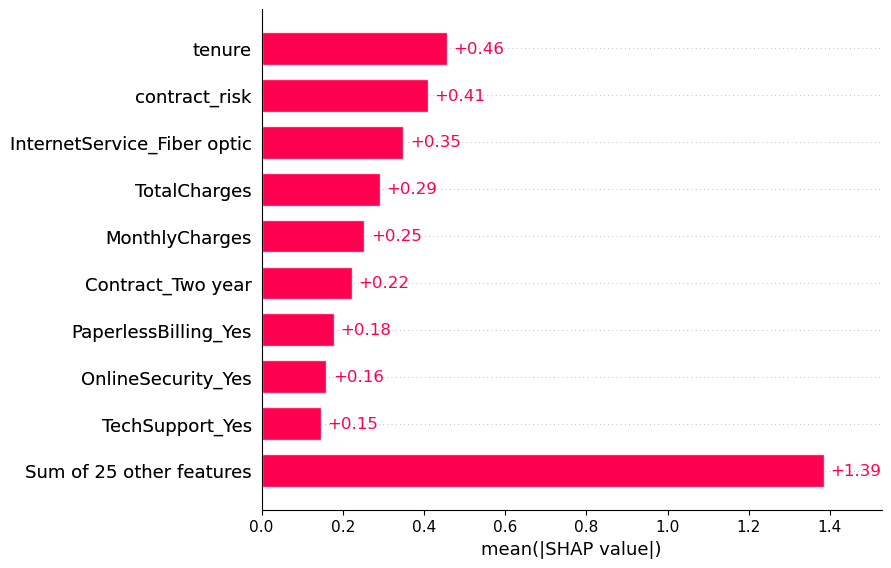

In [66]:
explainer = shap.Explainer(cat_model)
shap_values = explainer(X_test)

shap.plots.bar(shap_values, max_display=10)

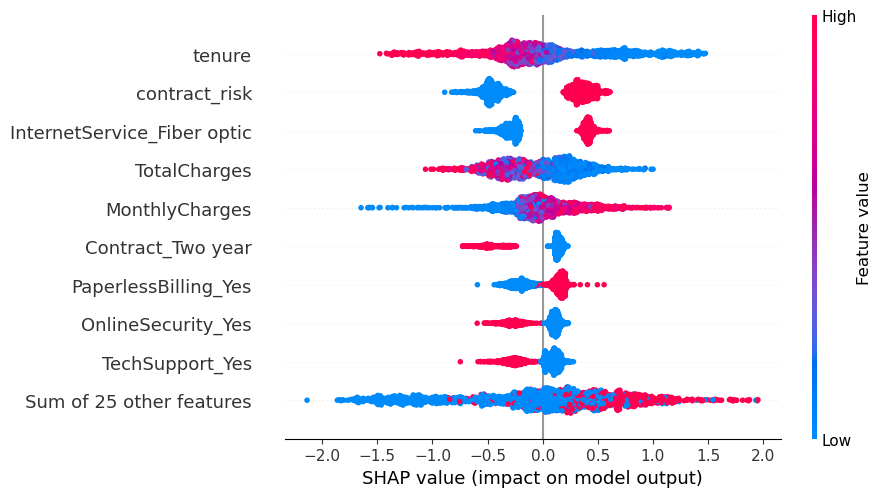

In [69]:
shap.plots.beeswarm(shap_values, max_display=10)

## MODEL COMPARISON VISUALIZATION

##### ROC-AUC Comparison Bar Chart

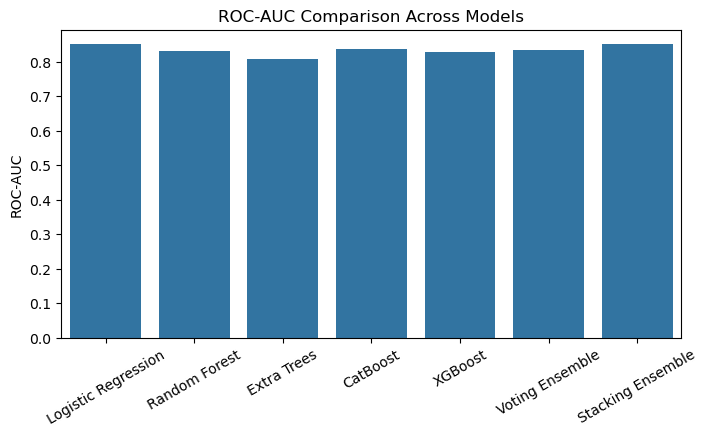

In [67]:
model_scores = {
    "Logistic Regression": roc_auc_score(y_test, lr_pred),
    "Random Forest": roc_auc_score(y_test, rf_pred),
    "Extra Trees": roc_auc_score(y_test, et_pred),
    "CatBoost": roc_auc_score(y_test, cat_pred),
    "XGBoost": roc_auc_score(y_test, xgb_pred),
    "Voting Ensemble": roc_auc_score(y_test, vote_pred),
    "Stacking Ensemble": roc_auc_score(y_test, stack_pred)
}

plt.figure(figsize=(8,4))
sns.barplot(
    x=list(model_scores.keys()),
    y=list(model_scores.values())
)
plt.xticks(rotation=30)
plt.title("ROC-AUC Comparison Across Models")
plt.ylabel("ROC-AUC")
plt.show()

## SAVE YOUR MODEL & THRESHOLD

In [75]:
import joblib

joblib.dump(stack, "churn_model.pkl")
joblib.dump(best_threshold, "threshold.pkl")

['threshold.pkl']

## Business Impact Summary

## Limitations & Future Work

## ATS-OPTIMIZED RESUME ENTRY (SHORT & POWERFUL)

#### ULTRA-SHORT VERSION (IF SPACE IS TIGHT)

## MOCK INTERVIEW EXPLANATION (HOW YOU SHOULD SPEAK)
##### 🎤 “Explain your churn prediction project.”

## INTERVIEW FOLLOW-UP QUESTIONS (WITH PERFECT ANSWERS)

## KILLER INTERVIEW STORY (STAR METHOD)

In [72]:
python --version


NameError: name 'python' is not defined

In [73]:
import sys
print(sys.version)


3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
